In [1]:
# Importing important libraries
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from keras.preprocessing.sequence import TimeseriesGenerator


In [2]:
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()
data = pd.read_csv(io.StringIO(uploaded['US Soybeans Futures Historical Data.csv'].decode('utf-8')))

Saving US Soybeans Futures Historical Data.csv to US Soybeans Futures Historical Data (2).csv


In [3]:
# Changing the format of the 'Date'column from object to datetime format
data['Date']=pd.to_datetime(data['Date'], infer_datetime_format=True)

In [4]:
# Converting "Price", "Open", "High", "Low", "Vol." columns to float datatype
data['Price'] = data['Price'].str.replace(',', '').astype(float)
data['Open'] = data['Open'].str.replace(',', '').astype(float)
data['High'] = data['High'].str.replace(',', '').astype(float)
data['Low'] = data['Low'].str.replace(',', '').astype(float)
data['Vol.'] = data['Vol.'].str.replace('K', '').astype(float) * 1000.
print(data.dtypes)

Date        datetime64[ns]
Price              float64
Open               float64
High               float64
Low                float64
Vol.               float64
Change %            object
dtype: object


In [5]:
# Drop the columns you don't need
data = data.drop(["Change %"], axis=1)

In [6]:
# fill missing values with mean of the column
data = data.fillna(data.mean())

# Check for null values in each column again
null_counts = data.isnull().sum()

# Print the number of null values in each column
print(null_counts)

Date     0
Price    0
Open     0
High     0
Low      0
Vol.     0
dtype: int64


<ipython-input-6-4e933ffb9d75>:2: FutureWarning: DataFrame.mean and DataFrame.median with numeric_only=None will include datetime64 and datetime64tz columns in a future version.
  data = data.fillna(data.mean())


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085 entries, 0 to 1084
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1085 non-null   datetime64[ns]
 1   Price   1085 non-null   float64       
 2   Open    1085 non-null   float64       
 3   High    1085 non-null   float64       
 4   Low     1085 non-null   float64       
 5   Vol.    1085 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 51.0 KB


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>, <Axes: xlabel='Date'>,
       <Axes: xlabel='Date'>], dtype=object)

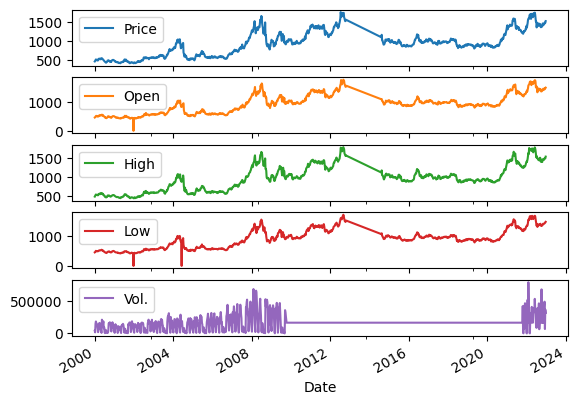

In [8]:
# Checking the correlation of each attribute with the date column
data.set_index('Date')[['Price','Open','High','Low', 'Vol.']].plot(subplots=True)

In [9]:
# Created a new dataframe which has all the columns
data_input=data[["Price",'Open','High','Low','Vol.']]
data_input

,Price,Open,High,Low,Vol.
0,1524.00,1495.75,1537.50,1485.00,321320.0
1,1479.00,1470.00,1489.00,1460.00,374100.0
2,1480.00,1482.12,1487.62,1457.75,69330.0
3,1483.75,1440.50,1492.75,1435.25,496710.0
4,1438.50,1428.25,1478.50,1424.00,420750.0
...,...,...,...,...,...
1080,505.50,519.50,519.50,495.00,165260.0
1081,523.50,510.25,529.50,508.00,187680.0
1082,505.25,489.00,507.50,486.50,151590.0
1083,485.50,468.00,490.00,464.00,17610.0


In [10]:
data_input.describe()

,Price,Open,High,Low,Vol.
count,1085.000000,1085.000000,1085.000000,1085.000000,1085.000000
mean,925.625548,923.974111,948.017687,901.644885,168395.089606
std,322.870920,323.264397,331.580002,314.104187,103435.556606
min,422.750000,0.000000,426.000000,0.000000,840.000000
25%,612.000000,612.750000,629.000000,598.500000,133680.000000
50%,919.120000,920.000000,941.380000,901.120000,168395.089606
75%,1100.620000,1094.000000,1140.000000,1053.000000,168395.089606
max,1758.380000,1772.630000,1788.880000,1725.630000,800250.000000


In [11]:
# Standardisation of the dataset to have a standard mean so that the gradience converges faster
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data_input)
data_scaled

array([[0.82451727, 0.84380271, 0.81555236, 0.86055528, 0.40089566],
       [0.7908253 , 0.82927627, 0.77996595, 0.84606781, 0.46691935],
       [0.79157401, 0.83611357, 0.77895339, 0.84476394, 0.08567569],
       ...,
       [0.0617686 , 0.27586129, 0.05979984, 0.28192602, 0.18857658],
       [0.04698157, 0.26401449, 0.04695938, 0.2688873 , 0.02097797],
       [0.03649963, 0.26006555, 0.03448579, 0.26410644, 0.05190078]])

In [12]:
# Extracting the target variable 
features=data_scaled #attributes include all the columns including the target
target=data_scaled[:,0] #target only the first column = price

In [13]:
# Taking two weeks data points to predict the third, hence length=2. 
TimeseriesGenerator(features, target, length=2, sampling_rate=1, batch_size=1)[0]

(array([[[0.82451727, 0.84380271, 0.81555236, 0.86055528, 0.40089566],
         [0.7908253 , 0.82927627, 0.77996595, 0.84606781, 0.46691935]]]),
 array([0.79157401]))

In [14]:
# Splitting the dataset in 98% train and 2% test dataset. 
# Shuffle=False because its a time series data
x_train, x_test, y_train, y_test= train_test_split(features, target, test_size=0.02, random_state=42, shuffle=False)

In [15]:
x_train.shape, x_test.shape

((1063, 5), (22, 5))

In [16]:
# Define TimeSeries Generator
win_length=4 #weekly dataset, so one month we have 4 datapoints
batch_size=32
num_features=5
train_generator= TimeseriesGenerator(x_train, y_train, length=win_length, sampling_rate=1, batch_size=batch_size)
test_generator= TimeseriesGenerator(x_test, y_test, length=win_length, sampling_rate=1, batch_size=batch_size)

In [17]:
train_generator[0] #32 observation cause of batch_size and each having window length of 4

(array([[[0.82451727, 0.84380271, 0.81555236, 0.86055528, 0.40089566],
         [0.7908253 , 0.82927627, 0.77996595, 0.84606781, 0.46691935],
         [0.79157401, 0.83611357, 0.77895339, 0.84476394, 0.08567569],
         [0.79438168, 0.81263433, 0.78271748, 0.83172522, 0.62029497]],
 
        [[0.7908253 , 0.82927627, 0.77996595, 0.84606781, 0.46691935],
         [0.79157401, 0.83611357, 0.77895339, 0.84476394, 0.08567569],
         [0.79438168, 0.81263433, 0.78271748, 0.83172522, 0.62029497],
         [0.76050253, 0.8057237 , 0.77226168, 0.82520587, 0.52527489]],
 
        [[0.79157401, 0.83611357, 0.77895339, 0.84476394, 0.08567569],
         [0.79438168, 0.81263433, 0.78271748, 0.83172522, 0.62029497],
         [0.76050253, 0.8057237 , 0.77226168, 0.82520587, 0.52527489],
         [0.75713334, 0.80466877, 0.74979455, 0.82129425, 0.20959844]],
 
        [[0.79438168, 0.81263433, 0.78271748, 0.83172522, 0.62029497],
         [0.76050253, 0.8057237 , 0.77226168, 0.82520587, 0.52527489

In [18]:
# LSTM model architecture
model=tf.keras.Sequential()
model.add(tf.keras.layers.LSTM(128, input_shape=(win_length, num_features), return_sequences=True))
model.add(tf.keras.layers.LeakyReLU(alpha=0.5)) #LeakyReLU activation function
model.add(tf.keras.layers.LSTM(128, return_sequences=True))
model.add(tf.keras.layers.LeakyReLU(alpha=0.5))
model.add(tf.keras.layers.Dropout(0.3))
model.add(tf.keras.layers.LSTM(128, return_sequences=False))
model.add(tf.keras.layers.Dropout(0.3))
model.add(tf.keras.layers.Dense(1))

In [19]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 4, 128)            68608     
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 4, 128)            0         
                                                                 
 lstm_1 (LSTM)               (None, 4, 128)            131584    
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 4, 128)            0         
                                                                 
 dropout (Dropout)           (None, 4, 128)            0         
                                                                 
 lstm_2 (LSTM)               (None, 128)               131584    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0

In [20]:
# Defining the model
early_stopping=tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, mode='min')

model.compile(loss=tf.losses.MeanSquaredError(), optimizer=tf.optimizers.Adam(), metrics=[tf.metrics.MeanAbsoluteError()])

history=model.fit_generator(train_generator, epochs=50, validation_data=test_generator, shuffle=False, callbacks=[early_stopping])

Epoch 1/50


<ipython-input-20-a45389fa3556>:6: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history=model.fit_generator(train_generator, epochs=50, validation_data=test_generator, shuffle=False, callbacks=[early_stopping])


34/34 [==============================] - 8s 62ms/step - loss: 0.0674 - mean_absolute_error: 0.1722 - val_loss: 9.2505e-04 - val_mean_absolute_error: 0.0267
Epoch 2/50
34/34 [==============================] - 1s 26ms/step - loss: 0.0374 - mean_absolute_error: 0.1295 - val_loss: 0.0021 - val_mean_absolute_error: 0.0435
Epoch 3/50
34/34 [==============================] - 2s 47ms/step - loss: 0.0203 - mean_absolute_error: 0.0969 - val_loss: 6.4645e-04 - val_mean_absolute_error: 0.0226
Epoch 4/50
34/34 [==============================] - 1s 26ms/step - loss: 0.0046 - mean_absolute_error: 0.0460 - val_loss: 5.6390e-04 - val_mean_absolute_error: 0.0204
Epoch 5/50
34/34 [==============================] - 1s 26ms/step - loss: 0.0057 - mean_absolute_error: 0.0560 - val_loss: 1.5282e-04 - val_mean_absolute_error: 0.0103
Epoch 6/50
34/34 [==============================] - 1s 25ms/step - loss: 0.0116 - mean_absolute_error: 0.0752 - val_loss: 3.6353e-04 - val_mean_absolute_error: 0.0159
Epoch 7/50
34

In [21]:
# Checking on models on the test part
model.evaluate_generator(test_generator)

<ipython-input-21-fb2167925083>:2: UserWarning: `Model.evaluate_generator` is deprecated and will be removed in a future version. Please use `Model.evaluate`, which supports generators.
  model.evaluate_generator(test_generator)


[0.0002043195127043873, 0.011752407066524029]

In [22]:
predictions=model.predict_generator(test_generator)

<ipython-input-22-6ca49477046f>:1: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  predictions=model.predict_generator(test_generator)


In [23]:
# Test data had 1000 datapoints and 4 win_length hence the prediction shape is 996 
predictions.shape[0]

18

In [24]:
predictions

array([[0.06597198],
       [0.07020159],
       [0.07490744],
       [0.07880119],
       [0.07405391],
       [0.06806306],
       [0.06806108],
       [0.06575105],
       [0.0645177 ],
       [0.06297699],
       [0.05987967],
       [0.05898861],
       [0.05625395],
       [0.05365621],
       [0.0523771 ],
       [0.05191764],
       [0.05096725],
       [0.0509553 ]], dtype=float32)

In [25]:
x_test, y_test

(array([[0.08310685, 0.2970163 , 0.07961082, 0.29684811, 0.15719093],
        [0.0834812 , 0.31168377, 0.0983212 , 0.30423671, 0.23534857],
        [0.09864259, 0.31591477, 0.09868807, 0.31090095, 0.26811023],
        [0.09639646, 0.30745277, 0.09978868, 0.31495744, 0.0107079 ],
        [0.09901694, 0.30068317, 0.10602548, 0.3088727 , 0.0344379 ],
        [0.0776787 , 0.3025166 , 0.08914945, 0.30278797, 0.11454698],
        [0.08497862, 0.2978625 , 0.08217892, 0.30481621, 0.06973893],
        [0.08217096, 0.3020935 , 0.09025006, 0.30438159, 0.15482668],
        [0.0868504 , 0.30688863, 0.09391876, 0.30481621, 0.20557661],
        [0.0919042 , 0.29927283, 0.08988319, 0.30336747, 0.17631753],
        [0.08086072, 0.29758043, 0.07924395, 0.30104947, 0.19184148],
        [0.08591451, 0.28150263, 0.08254579, 0.28916975, 0.14391864],
        [0.05783787, 0.28319503, 0.06200106, 0.28902488, 0.02428041],
        [0.06083272, 0.27924609, 0.05943297, 0.28540301, 0.07972129],
        [0.05559174,

In [26]:
# Creating a dataframe from the x_test which include the variables accept the 1st column
x_test[:,1][win_length:]

array([0.30068317, 0.3025166 , 0.2978625 , 0.3020935 , 0.30688863,
       0.29927283, 0.29758043, 0.28150263, 0.28319503, 0.27924609,
       0.28996463, 0.28418226, 0.28488743, 0.29306736, 0.28784913,
       0.27586129, 0.26401449, 0.26006555])

In [27]:
# Make prediction on the the previous dataframe
data.pred=pd.concat([pd.DataFrame(predictions), pd.DataFrame(x_test[:,1:][win_length:])], axis=1)
data.pred # Scaled values

<ipython-input-27-d0c09e8effeb>:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  data.pred=pd.concat([pd.DataFrame(predictions), pd.DataFrame(x_test[:,1:][win_length:])], axis=1)


,0,0,1,2,3
0,0.065972,0.300683,0.106025,0.308873,0.034438
1,0.070202,0.302517,0.089149,0.302788,0.114547
2,0.074907,0.297862,0.082179,0.304816,0.069739
3,0.078801,0.302093,0.090250,0.304382,0.154827
4,0.074054,0.306889,0.093919,0.304816,0.205577
5,0.068063,0.299273,0.089883,0.303367,0.176318
6,0.068061,0.297580,0.079244,0.301049,0.191841
7,0.065751,0.281503,0.082546,0.289170,0.143919
8,0.064518,0.283195,0.062001,0.289025,0.024280
9,0.062977,0.279246,0.059433,0.285403,0.079721


In [28]:
# Perform the reverse transform on the above scaled dataset
rev_trans=scaler.inverse_transform(data.pred)
rev_trans # Hence values are reversed to get the actual value

array([[   510.86415299,    533.        ,    570.5       ,
           533.        ,  28370.        ],
       [   516.51335053,    536.25      ,    547.5       ,
           522.5       ,  92410.        ],
       [   522.79862004,    528.        ,    538.        ,
           526.        ,  56590.        ],
       [   527.99923653,    535.5       ,    549.        ,
           525.25      , 124610.        ],
       [   521.65861834,    544.        ,    554.        ,
           526.        , 165180.        ],
       [   513.6570621 ,    530.5       ,    548.5       ,
           523.5       , 141790.        ],
       [   513.65442503,    527.5       ,    534.        ,
           519.5       , 154200.        ],
       [   510.56906949,    499.        ,    538.5       ,
           499.        , 115890.        ],
       [   508.92177456,    502.        ,    510.5       ,
           498.75      ,  20250.        ],
       [   506.86395204,    495.        ,    507.        ,
           492.5       

In [29]:
# Making final prediction. Count also matches the test dataframe
data_final=data_input[predictions.shape[0]*-1:]
data_final, data_final.count()

(       Price    Open   High     Low      Vol.
 1067  555.00  533.00  570.5  533.00   28370.0
 1068  526.50  536.25  547.5  522.50   92410.0
 1069  536.25  528.00  538.0  526.00   56590.0
 1070  532.50  535.50  549.0  525.25  124610.0
 1071  538.75  544.00  554.0  526.00  165180.0
 1072  545.50  530.50  548.5  523.50  141790.0
 1073  530.75  527.50  534.0  519.50  154200.0
 1074  537.50  499.00  538.5  499.00  115890.0
 1075  500.00  502.00  510.5  498.75   20250.0
 1076  504.00  495.00  507.0  492.50   64570.0
 1077  497.00  514.00  519.5  492.00  112580.0
 1078  514.50  503.75  516.0  501.50  140460.0
 1079  505.25  505.00  514.0  496.75  153960.0
 1080  505.50  519.50  519.5  495.00  165260.0
 1081  523.50  510.25  529.5  508.00  187680.0
 1082  505.25  489.00  507.5  486.50  151590.0
 1083  485.50  468.00  490.0  464.00   17610.0
 1084  471.50  461.00  473.0  455.75   42330.0,
 Price    18
 Open     18
 High     18
 Low      18
 Vol.     18
 dtype: int64)

In [30]:
# Adding the reversed predicted column in the original dataframe
data_final['Price Predicted']=rev_trans[:,0]
data_final

<ipython-input-30-0ad126213f07>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_final['Price Predicted']=rev_trans[:,0]


,Price,Open,High,Low,Vol.,Price Predicted
1067,555.00,533.00,570.5,533.00,28370.0,510.864153
1068,526.50,536.25,547.5,522.50,92410.0,516.513351
1069,536.25,528.00,538.0,526.00,56590.0,522.798620
1070,532.50,535.50,549.0,525.25,124610.0,527.999237
1071,538.75,544.00,554.0,526.00,165180.0,521.658618
1072,545.50,530.50,548.5,523.50,141790.0,513.657062
1073,530.75,527.50,534.0,519.50,154200.0,513.654425
1074,537.50,499.00,538.5,499.00,115890.0,510.569069
1075,500.00,502.00,510.5,498.75,20250.0,508.921775
1076,504.00,495.00,507.0,492.50,64570.0,506.863952


<Axes: >

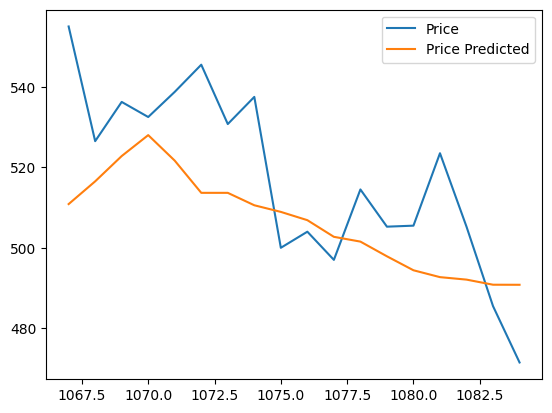

In [31]:
# Checking the prediction with the original price with the predicted price
data_final[['Price','Price Predicted']].plot()

In [32]:
!pip install dmba
from dmba import regressionSummary

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
no display found. Using non-interactive Agg backend


In [33]:
regressionSummary(data_final.Price, data_final['Price Predicted'])


Regression statistics

                      Mean Error (ME) : 11.0142
       Root Mean Squared Error (RMSE) : 19.0915
            Mean Absolute Error (MAE) : 15.6969
          Mean Percentage Error (MPE) : 2.0225
Mean Absolute Percentage Error (MAPE) : 2.9887
